<a href="https://colab.research.google.com/github/Nourin-Nusrat/CSE4261_DNN/blob/main/Assignment9/DNN_Assignment9_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Library Import

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# Transform with Single-Image Augmentations

In [2]:

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.RandomRotation(15),
    transforms.ToTensor()
])

test_transform = transforms.Compose([
    transforms.ToTensor()
])

# CIFAR-10 Datasets with Augmentation
train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, transform=train_transform, download=True)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, transform=test_transform, download=True)
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)
classes = train_dataset.classes

100%|██████████| 170M/170M [00:13<00:00, 12.6MB/s]


#CNN Architecture

In [3]:
class SimpleCNN(nn.Module):
    def __init__(self):
        super(SimpleCNN, self).__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2),
            nn.Conv2d(64, 128, 3, padding=1), nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )
        self.fc = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(),
            nn.Linear(256, 10)
        )

    def forward(self, x):
        x = self.conv(x)
        x = self.fc(x)
        return x

# Training Loop

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleCNN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

print("Training CNN with data augmentation...")
for epoch in range(10):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        loss = criterion(outputs, labels)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = outputs.max(1)
        correct += preds.eq(labels).sum().item()
        total += labels.size(0)

    acc = 100 * correct / total
    print(f"Epoch {epoch+1}: Loss={running_loss:.4f}, Accuracy={acc:.2f}%")

Training CNN with data augmentation...
Epoch 1: Loss=662.8547, Accuracy=38.35%
Epoch 2: Loss=529.8380, Accuracy=51.14%
Epoch 3: Loss=457.9908, Accuracy=58.41%
Epoch 4: Loss=418.2509, Accuracy=62.10%
Epoch 5: Loss=388.5835, Accuracy=64.79%
Epoch 6: Loss=366.4719, Accuracy=66.81%
Epoch 7: Loss=347.1700, Accuracy=68.63%
Epoch 8: Loss=329.8528, Accuracy=70.23%
Epoch 9: Loss=319.4852, Accuracy=71.36%
Epoch 10: Loss=308.1110, Accuracy=72.24%


# Evaluation

In [5]:
model.eval()
correct, total = 0, 0
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

test_acc = 100 * correct / total
print(f"\n✅ Test Accuracy (with augmentation): {test_acc:.2f}%")


✅ Test Accuracy (with augmentation): 76.28%


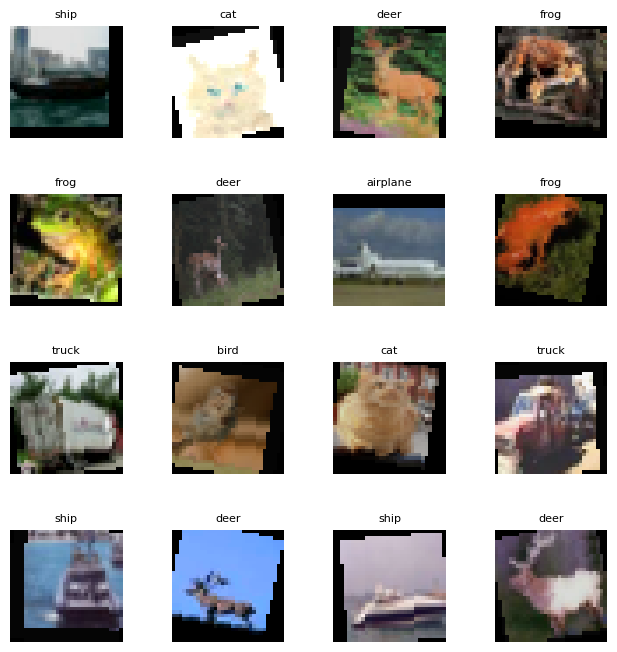

In [6]:
def show_augmented_images():
    import numpy as np
    import matplotlib.pyplot as plt

    # Get a batch of data
    dataiter = iter(train_loader)
    images, labels = next(dataiter)

    images = images[:16]  # First 16 images
    labels = labels[:16]

    # Convert tensor to numpy for plotting
    images = images.numpy()

    fig, axes = plt.subplots(4, 4, figsize=(8, 8))
    fig.subplots_adjust(hspace=0.5)

    for i, ax in enumerate(axes.flat):
        img = np.transpose(images[i], (1, 2, 0))  # CHW → HWC
        ax.imshow(img)
        ax.set_title(classes[labels[i]], fontsize=8)
        ax.axis('off')

    plt.show()

show_augmented_images()